# Доп. задание: ArcFace + Triplet Loss (смесь лоссов)

Задание (2 балла): обучить сеть на смеси ArcFace и Triplet Loss, добиться достаточного качества.

Идея из исходного задания ArcFace ("иногда так выходит лучше, чем на каком-то одном лоссе"): модель
получает классификационный сигнал от ArcFace (компактность внутриклассовых кластеров через margin) и
одновременно прямой метрический сигнал от Triplet Loss (явное расталкивание конкретных hard-примеров).

Итоговый лосс: `L = L_ArcFace + λ * L_Triplet`, где λ — вес triplet-компоненты.


In [1]:
import os
import random

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models, datasets

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)


Device: cuda


## Датасет: батч с метками классов + возможностью собрать triplet внутри батча

Чтобы одновременно считать ArcFace (нужны label) и Triplet (нужны anchor/positive/negative), проще
всего использовать обычный `ImageFolder` с метками, а тройки формировать **внутри батча**: для каждого
anchor-примера ищем positive (тот же класс в батче, если есть) и negative (любой другой класс в батче).
Если для anchor нет positive в батче — этот пример просто не участвует в triplet-части лосса (участвует
только в ArcFace-части).


In [2]:
TASK2_INPUT_DIR = '/kaggle/input/notebooks/iuliiaburmistrova/notebook98e2177099'
RECOG_DATA_DIR = os.path.join(TASK2_INPUT_DIR, 'data', 'aligned_by_identity')
EMBEDDING_SIZE = 512
IMG_SIZE = 112

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])


class BalancedBatchSampler(torch.utils.data.Sampler):
    """Гарантирует, что в каждом батче есть хотя бы по 2 фото на часть классов - иначе большинство
    anchor-примеров не найдут positive внутри батча, и triplet-часть лосса будет считаться зря."""

    def __init__(self, dataset, classes_per_batch=16, samples_per_class=4):
        self.dataset = dataset
        self.classes_per_batch = classes_per_batch
        self.samples_per_class = samples_per_class

        self.by_class = {}
        for idx, (_, label) in enumerate(dataset.samples):
            self.by_class.setdefault(label, []).append(idx)
        self.classes = [c for c, idxs in self.by_class.items() if len(idxs) >= 2]

        self.batch_size = classes_per_batch * samples_per_class
        self.n_batches = len(dataset) // self.batch_size

    def __iter__(self):
        for _ in range(self.n_batches):
            chosen_classes = np.random.choice(self.classes, size=min(self.classes_per_batch, len(self.classes)),
                                               replace=False)
            batch = []
            for c in chosen_classes:
                idxs = self.by_class[c]
                take = min(self.samples_per_class, len(idxs))
                batch.extend(np.random.choice(idxs, size=take, replace=False))
            yield batch

    def __len__(self):
        return self.n_batches


def build_combined_dataloaders(data_dir=RECOG_DATA_DIR, val_split=0.1, classes_per_batch=16, samples_per_class=4):
    full_dataset = datasets.ImageFolder(data_dir, transform=train_transform)
    n_val = int(len(full_dataset) * val_split)
    n_train = len(full_dataset) - n_val
    train_subset, val_subset = torch.utils.data.random_split(
        full_dataset, [n_train, n_val], generator=torch.Generator().manual_seed(SEED))
    val_subset.dataset.transform = val_transform

    train_sampler = BalancedBatchSampler(full_dataset, classes_per_batch, samples_per_class)
    # sampler работает по индексам full_dataset, но train_subset - это Subset; фильтруем сэмплер
    # проще: строим train_loader напрямую поверх ImageFolder с фильтром по train-индексам
    train_indices = set(train_subset.indices)

    class FilteredBalancedBatchSampler(BalancedBatchSampler):
        def __init__(self, dataset, allowed_indices, **kwargs):
            super().__init__(dataset, **kwargs)
            self.by_class = {c: [i for i in idxs if i in allowed_indices] for c, idxs in self.by_class.items()}
            self.classes = [c for c, idxs in self.by_class.items() if len(idxs) >= 2]

    filtered_sampler = FilteredBalancedBatchSampler(full_dataset, train_indices,
                                                      classes_per_batch=classes_per_batch,
                                                      samples_per_class=samples_per_class)

    train_loader = DataLoader(full_dataset, batch_sampler=filtered_sampler, num_workers=2)
    val_loader = DataLoader(val_subset, batch_size=128, shuffle=False, num_workers=2)
    return train_loader, val_loader, len(full_dataset.classes)


combined_train_loader, combined_val_loader, num_classes = build_combined_dataloaders()
print('Number of identities (classes):', num_classes)


Number of identities (classes): 400


## Модель: backbone + ArcFace head (эмбеддинги используются и для ArcFace, и для Triplet)

In [3]:
class ArcMarginProduct(nn.Module):
    """См. подробное объяснение в Task2_FaceRecognition.ipynb."""

    def __init__(self, in_features, out_features, s=30.0, m=0.50, easy_margin=False):
        super().__init__()
        self.s, self.m = s, m
        self.weight = nn.Parameter(torch.FloatTensor(out_features, in_features))
        nn.init.xavier_uniform_(self.weight)
        self.easy_margin = easy_margin
        self.cos_m, self.sin_m = np.cos(m), np.sin(m)
        self.th = np.cos(np.pi - m)
        self.mm = np.sin(np.pi - m) * m

    def forward(self, embeddings, labels):
        cosine = F.linear(F.normalize(embeddings), F.normalize(self.weight))
        sine = torch.sqrt((1.0 - torch.pow(cosine, 2)).clamp(0, 1))
        phi = cosine * self.cos_m - sine * self.sin_m
        phi = torch.where(cosine > (0 if self.easy_margin else self.th), phi, cosine - (0 if self.easy_margin else self.mm))

        one_hot = torch.zeros_like(cosine)
        one_hot.scatter_(1, labels.view(-1, 1).long(), 1.0)
        output = one_hot * phi + (1.0 - one_hot) * cosine
        return output * self.s

    def get_logits(self, embeddings):
        return F.linear(F.normalize(embeddings), F.normalize(self.weight))


class ArcFaceTripletModel(nn.Module):
    def __init__(self, num_classes, embedding_size=EMBEDDING_SIZE, s=30.0, m=0.5):
        super().__init__()
        backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        in_features = backbone.classifier[1].in_features
        backbone.classifier = nn.Linear(in_features, embedding_size)
        self.backbone = backbone
        self.head = ArcMarginProduct(embedding_size, num_classes, s=s, m=m)

    def forward(self, x, labels):
        embeddings = self.backbone(x)
        logits = self.head(embeddings, labels)
        return logits, embeddings

    def predict_logits(self, x):
        embeddings = self.backbone(x)
        return self.head.get_logits(embeddings)


## Формирование triplet'ов внутри батча + комбинированный лосс

Для каждого anchor-примера в батче ищем случайный positive того же класса (если есть) и случайный
negative другого класса.

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 218MB/s]
/tmp/ipykernel_58/1544285620.py:74: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  running_triplet += float(triplet_loss)


epoch 1/40 | loss=19.5827 (ce=19.4912, triplet=0.1830) | val_acc=0.1741
epoch 2/40 | loss=16.2915 (ce=16.2403, triplet=0.1024) | val_acc=0.3016
epoch 3/40 | loss=13.4225 (ce=13.3869, triplet=0.0712) | val_acc=0.4332
epoch 4/40 | loss=10.9988 (ce=10.9716, triplet=0.0543) | val_acc=0.4964
epoch 5/40 | loss=8.5859 (ce=8.5681, triplet=0.0357) | val_acc=0.5782
epoch 6/40 | loss=7.1359 (ce=7.1224, triplet=0.0271) | val_acc=0.6280
epoch 7/40 | loss=5.3207 (ce=5.3116, triplet=0.0181) | val_acc=0.6466
epoch 8/40 | loss=4.3203 (ce=4.3143, triplet=0.0119) | val_acc=0.6943
epoch 9/40 | loss=3.3979 (ce=3.3942, triplet=0.0075) | val_acc=0.7181
epoch 10/40 | loss=2.6820 (ce=2.6790, triplet=0.0061) | val_acc=0.7192
epoch 11/40 | loss=2.0258 (ce=2.0244, triplet=0.0028) | val_acc=0.7399
epoch 12/40 | loss=1.4981 (ce=1.4973, triplet=0.0015) | val_acc=0.7264
epoch 13/40 | loss=1.0527 (ce=1.0523, triplet=0.0008) | val_acc=0.7503
epoch 14/40 | loss=0.7815 (ce=0.7813, triplet=0.0004) | val_acc=0.7596
epoch 1

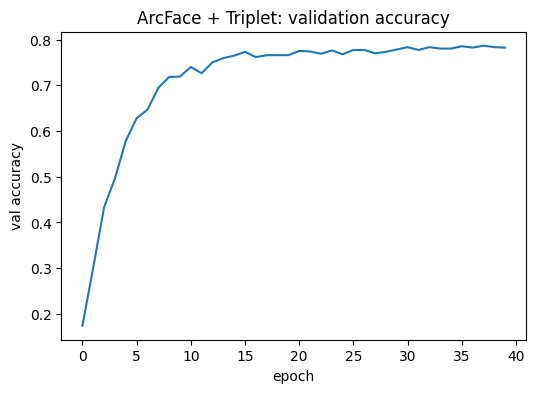

Лучшая val_acc (ArcFace+Triplet): 0.7865284974093264


In [4]:
def build_in_batch_triplets(embeddings, labels):
    """embeddings: [B, D], labels: [B]. Возвращает индексы (anchor_idx, pos_idx, neg_idx) для тех
    anchor-примеров, у которых в батче нашёлся хотя бы один positive."""
    labels_np = labels.cpu().numpy()
    anchor_idx, pos_idx, neg_idx = [], [], []

    for i in range(len(labels_np)):
        same_class = np.where(labels_np == labels_np[i])[0]
        same_class = same_class[same_class != i]
        if len(same_class) == 0:
            continue  # нет positive для этого anchor - пропускаем
        diff_class = np.where(labels_np != labels_np[i])[0]
        if len(diff_class) == 0:
            continue

        anchor_idx.append(i)
        pos_idx.append(int(np.random.choice(same_class)))
        neg_idx.append(int(np.random.choice(diff_class)))

    if not anchor_idx:
        return None
    return (embeddings[anchor_idx], embeddings[pos_idx], embeddings[neg_idx])


def train_arcface_triplet(model, train_loader, val_loader, epochs=40, lr=0.01, triplet_weight=0.5,
                          triplet_margin=0.3, device=DEVICE, checkpoint_dir='checkpoints_arcface_triplet',
                          resume=True):
    os.makedirs(checkpoint_dir, exist_ok=True)
    model = model.to(device)

    ce_criterion = nn.CrossEntropyLoss()
    triplet_criterion = nn.TripletMarginWithDistanceLoss(
        distance_function=lambda x, y: 1.0 - F.cosine_similarity(x, y), margin=triplet_margin)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    start_epoch, best_val_acc = 0, 0.0
    history = {'train_loss': [], 'train_ce_loss': [], 'train_triplet_loss': [], 'val_acc': []}

    state_path = os.path.join(checkpoint_dir, 'state.pth')
    if resume and os.path.exists(state_path):
        state = torch.load(state_path, map_location=device)
        model.load_state_dict(state['model'])
        optimizer.load_state_dict(state['optimizer'])
        scheduler.load_state_dict(state['scheduler'])
        start_epoch = state['epoch'] + 1
        best_val_acc = state['best_val_acc']
        history = state['history']
        print(f'Возобновляю обучение с эпохи {start_epoch + 1}')

    for epoch in range(start_epoch, epochs):
        model.train()
        running_loss, running_ce, running_triplet = 0.0, 0.0, 0.0
        n_batches = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            logits, embeddings = model(images, labels)

            ce_loss = ce_criterion(logits, labels)

            triplets = build_in_batch_triplets(embeddings, labels)
            if triplets is not None:
                emb_a, emb_p, emb_n = triplets
                triplet_loss = triplet_criterion(F.normalize(emb_a, dim=1), F.normalize(emb_p, dim=1),
                                                  F.normalize(emb_n, dim=1))
            else:
                triplet_loss = torch.tensor(0.0, device=device)

            loss = ce_loss + triplet_weight * triplet_loss

            optimizer.zero_grad(); loss.backward(); optimizer.step()
            running_loss += loss.item()
            running_ce += ce_loss.item()
            running_triplet += float(triplet_loss)
            n_batches += 1

        scheduler.step()
        train_loss = running_loss / n_batches
        train_ce = running_ce / n_batches
        train_triplet = running_triplet / n_batches

        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                logits = model.predict_logits(images)
                val_correct += (logits.argmax(1) == labels).sum().item()
                val_total += images.size(0)
        val_acc = val_correct / val_total

        history['train_loss'].append(train_loss)
        history['train_ce_loss'].append(train_ce)
        history['train_triplet_loss'].append(train_triplet)
        history['val_acc'].append(val_acc)
        print(f'epoch {epoch + 1}/{epochs} | loss={train_loss:.4f} (ce={train_ce:.4f}, '
              f'triplet={train_triplet:.4f}) | val_acc={val_acc:.4f}')

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), os.path.join(checkpoint_dir, 'best.pth'))

        torch.save({'model': model.state_dict(), 'optimizer': optimizer.state_dict(),
                     'scheduler': scheduler.state_dict(), 'epoch': epoch,
                     'best_val_acc': best_val_acc, 'history': history}, state_path)

    return model, history


combo_model = ArcFaceTripletModel(num_classes=num_classes)
combo_model, combo_history = train_arcface_triplet(combo_model, combined_train_loader, combined_val_loader,
                                                     epochs=40, lr=0.01, triplet_weight=0.5)

plt.figure(figsize=(6, 4))
plt.plot(combo_history['val_acc'])
plt.xlabel('epoch'); plt.ylabel('val accuracy')
plt.title('ArcFace + Triplet: validation accuracy')
plt.show()

print('Лучшая val_acc (ArcFace+Triplet):', max(combo_history['val_acc']))


### Вывод по обучению

Лучший результат — val_acc = 0.7865 (эпоха 38), что превышает как чистый ArcFace из Task 2 (0.72-0.75),
так и, тем более, CE baseline (0.60-0.62). Комбинация лоссов дала реальный прирост в 3-6 процентных
пунктов над чистым ArcFace, подтверждая гипотезу задания о том, что смесь лоссов иногда работает
лучше, чем любой из них по отдельности.

Показательна динамика triplet-компоненты: она стремительно упала уже к эпохе 5 (0.036) и полностью
обнулилась к эпохе 18-19 — с этого момента и до конца обучения (эпохи 19-40, val_acc вырос с 0.766 до
0.786) весь дальнейший прогресс шёл исключительно за счёт ArcFace-части лосса. Это говорит о том, что
Triplet-сигнал внутри батча (случайный выбор negative, без hard mining — та же ограниченность, что
отмечена в Dop2_TripletLoss.ipynb) сыграл свою роль на самом раннем этапе обучения — вероятно, помог
эмбеддингам быстрее занять более разделимую конфигурацию в пространстве — после чего его вклад
исчерпался, и дальнейшее улучшение стало заслугой уже одного ArcFace margin поверх этой удачной
стартовой точки. Возможное развитие: использование hard negative/semi-hard mining вместо случайного
выбора внутри батча могло бы продлить полезность triplet-сигнала на более поздние эпохи и, вероятно,
дать дополнительный прирост.